<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Photobiomodulation_Effects_on_Hemodynamic_Pressure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 452ms


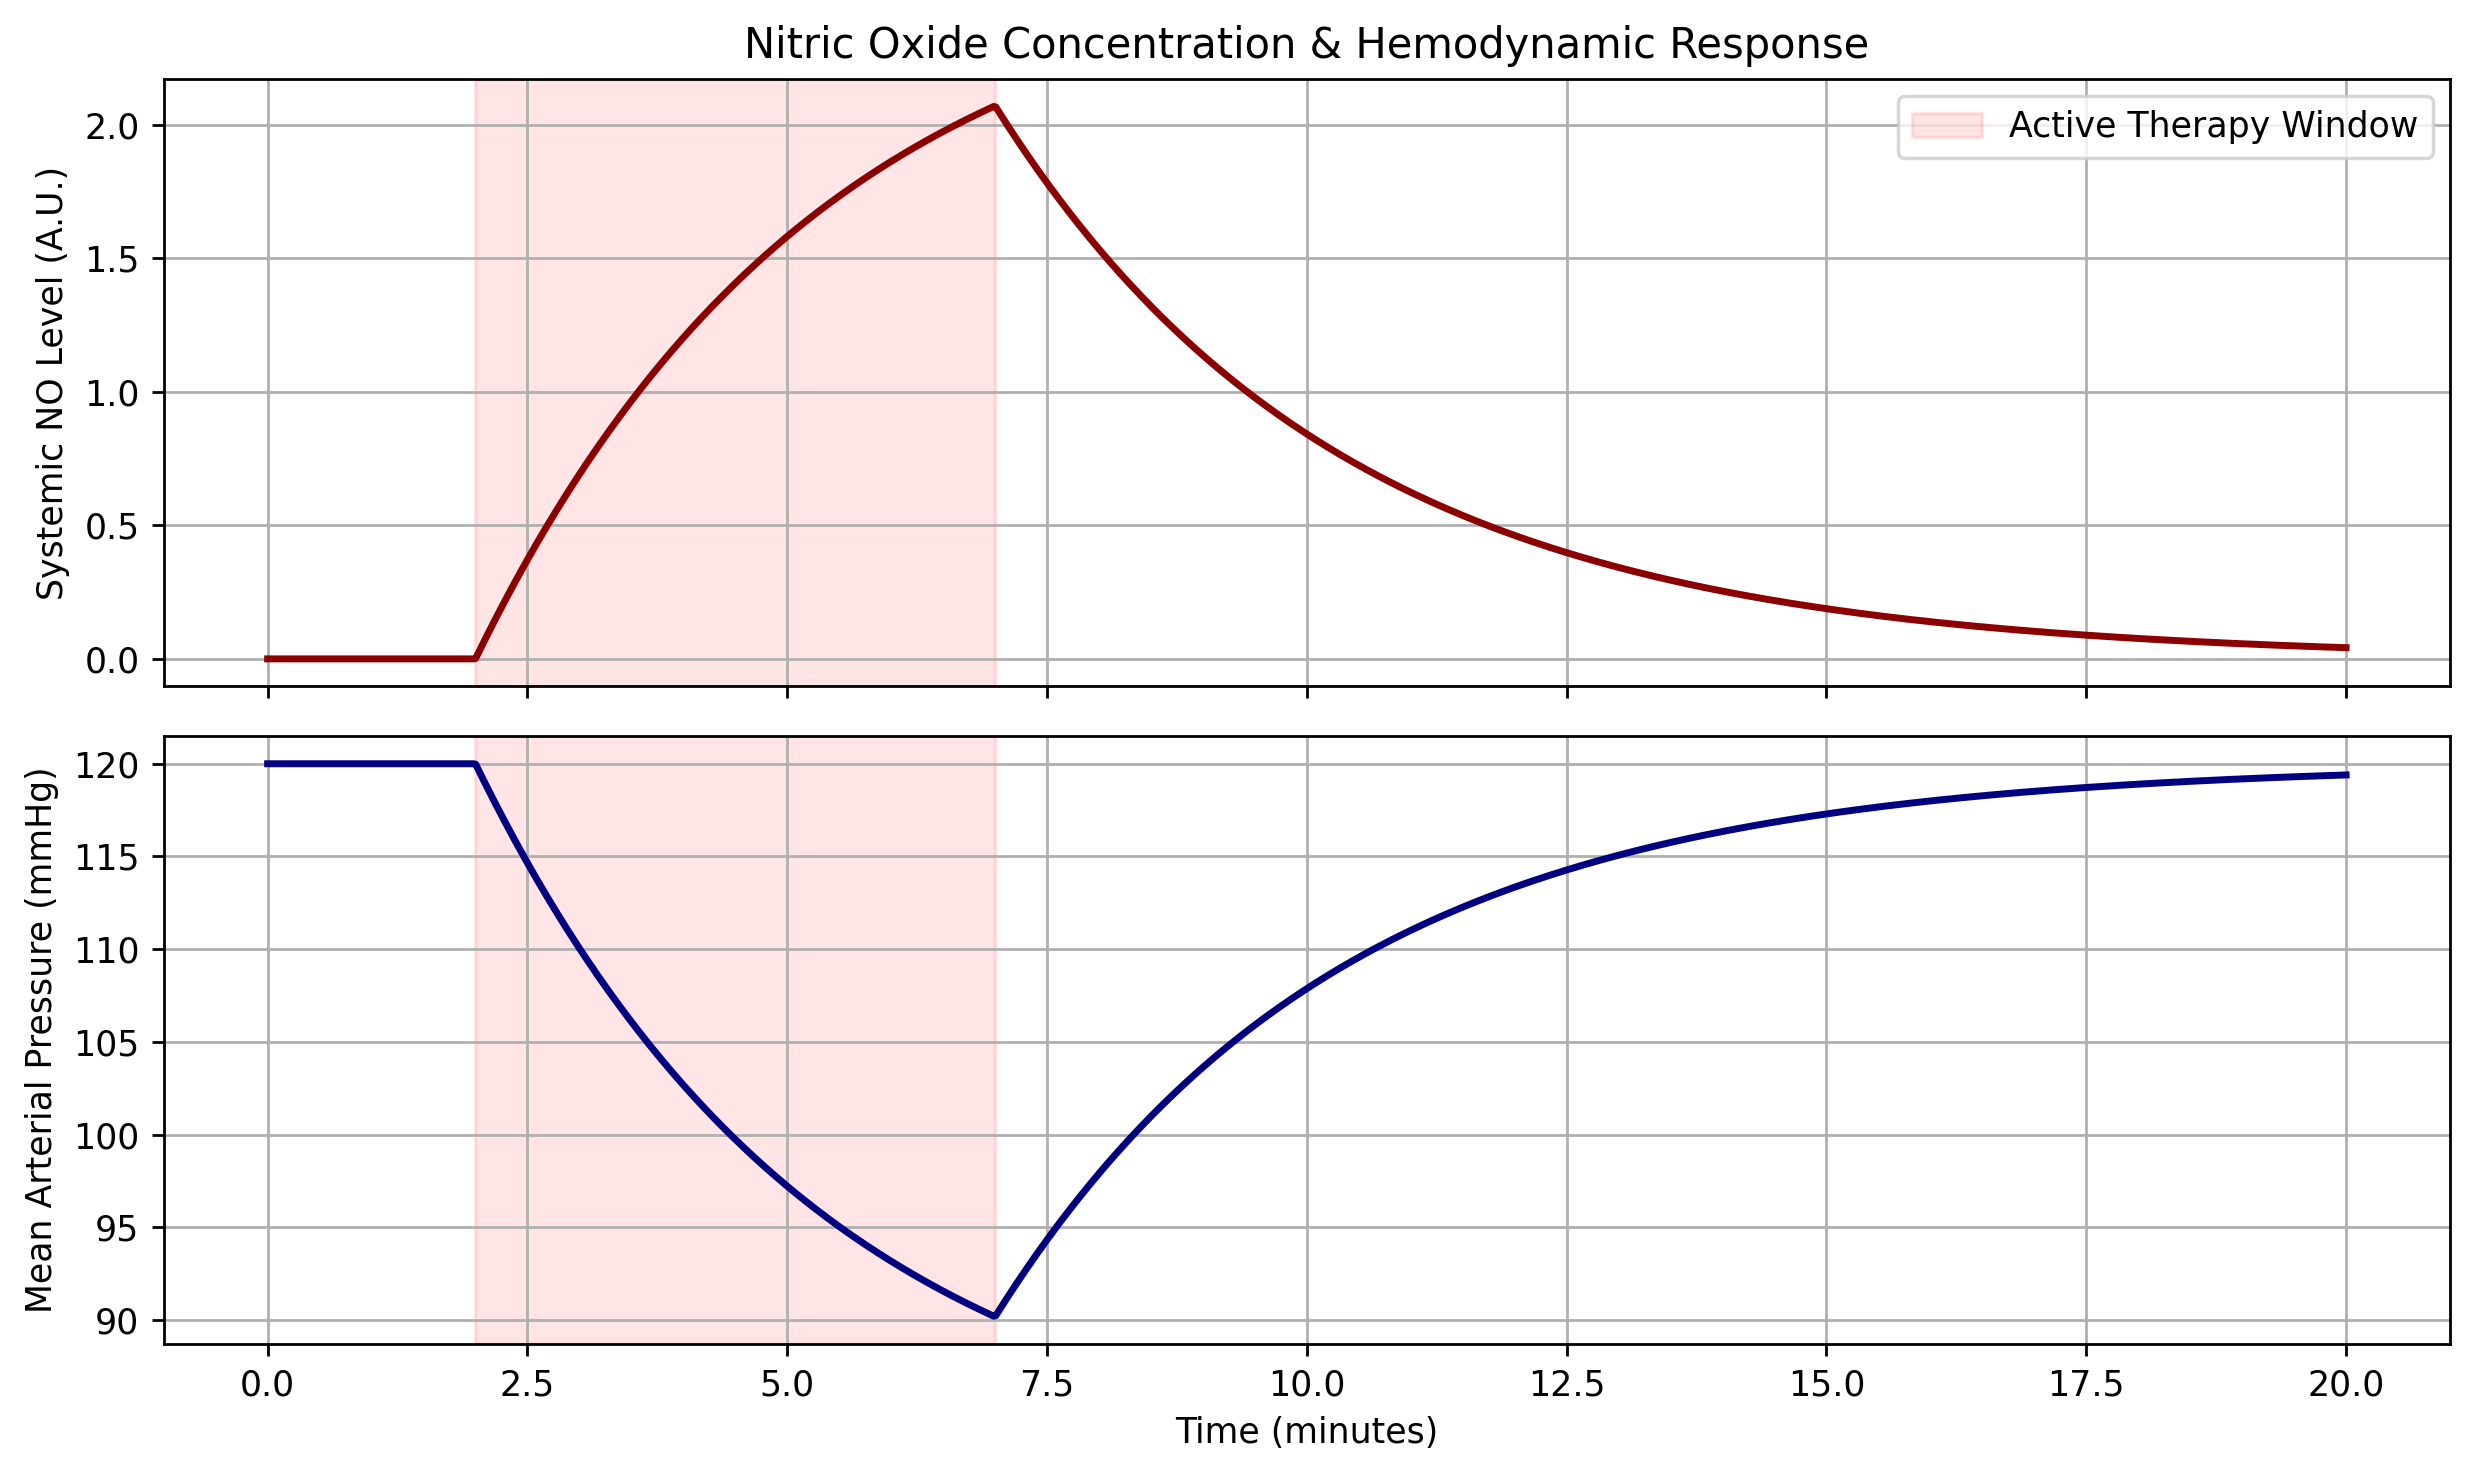

In [2]:
!uv pip install numpy scipy matplotlib

"""
Simulates the hemodynamic pressure response to brief photobiomodulation therapy.
This script employs a numerical differential equation solver to model
nitric oxide kinetics and subsequent vasodilation.
"""

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Colab rendering parameters
plt.rcParams['figure.dpi'] = 250
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# =============================================================================
# CONTROL KNOBS (Adjustable Physiological & Simulation Parameters)
# =============================================================================
PBM_START_TIME = 2.0             # Time (minutes) when light therapy begins
PBM_DURATION = 5.0               # Duration (minutes) of light therapy
SIMULATION_END_TIME = 20.0       # Total duration (minutes) of the simulation
TIME_STEPS = 1000                # Resolution of the numerical simulation

BASELINE_MAP = 120.0             # Initial Mean Arterial Pressure (mmHg)
BASELINE_TPR = 1.0               # Normalized Total Peripheral Resistance
CARDIAC_OUTPUT = BASELINE_MAP / BASELINE_TPR # Assuming constant CO throughout

NO_PRODUCTION_RATE = 0.8         # k_prod: Rate of NO release during irradiance
NO_DECAY_RATE = 0.3              # k_decay: Biological half-life decay factor
VASODILATION_SENSITIVITY = 0.12  # alpha: Sensitivity of TPR to NO concentration
# =============================================================================

def irradiance_function(t):
    """
    Determines the active state of the light therapy device at a given time.
    Returns 1.0 if the therapy is active, and 0.0 otherwise.
    """
    if PBM_START_TIME <= t <= (PBM_START_TIME + PBM_DURATION):
        return 1.0
    return 0.0

def nitric_oxide_kinetics(no_concentration, t):
    """
    Calculates the derivative of nitric oxide concentration over time.
    """
    production = NO_PRODUCTION_RATE * irradiance_function(t)
    decay = NO_DECAY_RATE * no_concentration
    return production - decay

def run_simulation():
    """
    Executes the numerical integration and visualizes the physiological response.
    """
    time_array = np.linspace(0, SIMULATION_END_TIME, TIME_STEPS)
    initial_no_concentration = 0.0

    # Solve the ordinary differential equation for NO concentration
    no_solution = odeint(
        nitric_oxide_kinetics,
        initial_no_concentration,
        time_array
    ).flatten()

    # Calculate the corresponding physiological changes
    tpr_array = BASELINE_TPR * (1.0 - VASODILATION_SENSITIVITY * no_solution)
    map_array = CARDIAC_OUTPUT * tpr_array

    # Construct the continuous visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    ax1.plot(time_array, no_solution, color='darkred', linewidth=2.0)
    ax1.axvspan(
        PBM_START_TIME,
        PBM_START_TIME + PBM_DURATION,
        color='red',
        alpha=0.1,
        label='Active Therapy Window'
    )
    ax1.set_ylabel('Systemic NO Level (A.U.)')
    ax1.set_title('Nitric Oxide Concentration & Hemodynamic Response')
    ax1.legend(loc='upper right')

    ax2.plot(time_array, map_array, color='navy', linewidth=2.0)
    ax2.axvspan(
        PBM_START_TIME,
        PBM_START_TIME + PBM_DURATION,
        color='red',
        alpha=0.1
    )
    ax2.set_xlabel('Time (minutes)')
    ax2.set_ylabel('Mean Arterial Pressure (mmHg)')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_simulation()